In [1]:
!pwd

/home/koollio/Projects/Python/learning/code


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [4]:
db = json.load(open("../data/database.json"))

len(db)

6636

In [7]:
len(db[0])

7

In [9]:
db[0].keys()

dict_keys(['id', 'description', 'tags', 'manufacturer', 'group', 'portions', 'nutrients'])

In [12]:
db[0]["nutrients"][0].keys()

dict_keys(['value', 'units', 'description', 'group'])

In [13]:
db[0]["nutrients"][0]

{'value': 25.18,
 'units': 'g',
 'description': 'Protein',
 'group': 'Composition'}

In [15]:
nutrients = pd.DataFrame(db[0]["nutrients"])
nutrients

,value,units,description,group
0,25.180,g,Protein,Composition
1,29.200,g,Total lipid (fat),Composition
2,3.060,g,"Carbohydrate, by difference",Composition
3,3.280,g,Ash,Other
4,376.000,kcal,Energy,Energy
...,...,...,...,...
157,1.472,g,Serine,Amino Acids
158,93.000,mg,Cholesterol,Other
159,18.584,g,"Fatty acids, total saturated",Other
160,8.275,g,"Fatty acids, total monounsaturated",Other


In [17]:
info_keys = ["id", "description", "manufacturer", "group"]
info = pd.DataFrame(db, columns=info_keys)
info

,id,description,manufacturer,group
0,1008,"Cheese, caraway",,Dairy and Egg Products
1,1009,"Cheese, cheddar",,Dairy and Egg Products
2,1018,"Cheese, edam",,Dairy and Egg Products
3,1019,"Cheese, feta",,Dairy and Egg Products
4,1028,"Cheese, mozzarella, part skim milk",,Dairy and Egg Products
...,...,...,...,...
6631,42161,"Bologna, beef, low fat",,Sausages and Luncheon Meats
6632,42173,"Turkey and pork sausage, fresh, bulk, patty or...",,Sausages and Luncheon Meats
6633,43408,"Babyfood, juice, pear",None,Baby Foods
6634,43539,"Babyfood, dessert, banana yogurt, strained",None,Baby Foods


In [19]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            6636 non-null   int64 
 1   description   6636 non-null   object
 2   manufacturer  5195 non-null   object
 3   group         6636 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


In [20]:
6636-5195

1441

### View distributions using value_counts

In [22]:
pd.Series(info["group"]).value_counts()

group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Beverages                            278
Soups, Sauces, and Gravies           275
Finfish and Shellfish Products       255
Baby Foods                           209
Cereal Grains and Pasta              183
Ethnic Foods                         165
Snacks                               162
Nut and Seed Products                128
Poultry Products                     116
Sausages and Luncheon Meats          111
Dairy and Egg Products               107
Fats and Oils                         97
Meals, Entrees, and Sidedishes        57
Restaurant Foods                      51
Spices and

In [24]:
nutrients

,value,units,description,group
0,25.180,g,Protein,Composition
1,29.200,g,Total lipid (fat),Composition
2,3.060,g,"Carbohydrate, by difference",Composition
3,3.280,g,Ash,Other
4,376.000,kcal,Energy,Energy
...,...,...,...,...
157,1.472,g,Serine,Amino Acids
158,93.000,mg,Cholesterol,Other
159,18.584,g,"Fatty acids, total saturated",Other
160,8.275,g,"Fatty acids, total monounsaturated",Other


In [46]:
db[:2]

[{'id': 1008,
  'description': 'Cheese, caraway',
  'tags': [],
  'manufacturer': '',
  'group': 'Dairy and Egg Products',
  'portions': [{'amount': 1, 'unit': 'oz', 'grams': 28.35}],
  'nutrients': [{'value': 25.18,
    'units': 'g',
    'description': 'Protein',
    'group': 'Composition'},
   {'value': 29.2,
    'units': 'g',
    'description': 'Total lipid (fat)',
    'group': 'Composition'},
   {'value': 3.06,
    'units': 'g',
    'description': 'Carbohydrate, by difference',
    'group': 'Composition'},
   {'value': 3.28, 'units': 'g', 'description': 'Ash', 'group': 'Other'},
   {'value': 376.0,
    'units': 'kcal',
    'description': 'Energy',
    'group': 'Energy'},
   {'value': 39.28,
    'units': 'g',
    'description': 'Water',
    'group': 'Composition'},
   {'value': 1573.0,
    'units': 'kJ',
    'description': 'Energy',
    'group': 'Energy'},
   {'value': 0.0,
    'units': 'g',
    'description': 'Fiber, total dietary',
    'group': 'Composition'},
   {'value': 673.0,


In [26]:
nutrients = []

for rec in db:
    fnuts = pd.DataFrame(rec["nutrients"])
    fnuts["id"] = rec["id"]
    nutrients.append(fnuts)

nutrients = pd.concat(nutrients, ignore_index=True)
    

In [27]:
nutrients

,value,units,description,group,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


In [29]:
nutrients["description"].str.split(",").explode()

0                        Protein
1              Total lipid (fat)
2                   Carbohydrate
2                  by difference
3                            Ash
                   ...          
389352           total saturated
389353               Fatty acids
389353     total monounsaturated
389354               Fatty acids
389354     total polyunsaturated
Name: description, Length: 560224, dtype: object

In [32]:
# deal with duplicates
nutrients.duplicated().sum()
nutrients.drop_duplicates(inplace=True)

In [33]:
nutrients

,value,units,description,group,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


In [34]:
# what variables are defined. Too lazy to scroll up
%who

db	 fnuts	 info	 info_keys	 json	 np	 nutrients	 pd	 plt	 
rec	 


In [35]:
info.head()

,id,description,manufacturer,group
0,1008,"Cheese, caraway",,Dairy and Egg Products
1,1009,"Cheese, cheddar",,Dairy and Egg Products
2,1018,"Cheese, edam",,Dairy and Egg Products
3,1019,"Cheese, feta",,Dairy and Egg Products
4,1028,"Cheese, mozzarella, part skim milk",,Dairy and Egg Products


In [37]:
print("Info columns are: ", info.columns)
print("Nutrient columns are: ", nutrients.columns)

Info columns are:  Index(['id', 'description', 'manufacturer', 'group'], dtype='object')
Nutrient columns are:  Index(['value', 'units', 'description', 'group', 'id'], dtype='object')


In [38]:
# Replace description with a shorter name and group too
col_mapping = {"description": "food", 
               "group": "fgroup"}

In [41]:
info.rename(columns=col_mapping, copy=False, inplace=True)

In [42]:
info

,id,food,manufacturer,fgroup
0,1008,"Cheese, caraway",,Dairy and Egg Products
1,1009,"Cheese, cheddar",,Dairy and Egg Products
2,1018,"Cheese, edam",,Dairy and Egg Products
3,1019,"Cheese, feta",,Dairy and Egg Products
4,1028,"Cheese, mozzarella, part skim milk",,Dairy and Egg Products
...,...,...,...,...
6631,42161,"Bologna, beef, low fat",,Sausages and Luncheon Meats
6632,42173,"Turkey and pork sausage, fresh, bulk, patty or...",,Sausages and Luncheon Meats
6633,43408,"Babyfood, juice, pear",None,Baby Foods
6634,43539,"Babyfood, dessert, banana yogurt, strained",None,Baby Foods


In [43]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            6636 non-null   int64 
 1   food          6636 non-null   object
 2   manufacturer  5195 non-null   object
 3   fgroup        6636 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


In [44]:
# Replace description with a shorter name and group too
col_mapping = {"description": "nutrient", 
               "group": "nutgroup"}

nutrients.rename(columns=col_mapping, inplace=True, copy=False)
nutrients

,value,units,nutrient,nutgroup,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


In [47]:
# time to merge the info df with the nutrients
foodf = pd.merge(nutrients, info, on="id")
foodf

,value,units,nutrient,nutgroup,id,food,manufacturer,fgroup
0,25.180,g,Protein,Composition,1008,"Cheese, caraway",,Dairy and Egg Products
1,29.200,g,Total lipid (fat),Composition,1008,"Cheese, caraway",,Dairy and Egg Products
2,3.060,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",,Dairy and Egg Products
3,3.280,g,Ash,Other,1008,"Cheese, caraway",,Dairy and Egg Products
4,376.000,kcal,Energy,Energy,1008,"Cheese, caraway",,Dairy and Egg Products
...,...,...,...,...,...,...,...,...
375171,0.000,mcg,"Vitamin B-12, added",Vitamins,43546,"Babyfood, banana no tapioca, strained",None,Baby Foods
375172,0.000,mg,Cholesterol,Other,43546,"Babyfood, banana no tapioca, strained",None,Baby Foods
375173,0.072,g,"Fatty acids, total saturated",Other,43546,"Babyfood, banana no tapioca, strained",None,Baby Foods
375174,0.028,g,"Fatty acids, total monounsaturated",Other,43546,"Babyfood, banana no tapioca, strained",None,Baby Foods


In [48]:
foodf.iloc[375000]

value                                                        79.0
units                                                          IU
nutrient                                                Vitamin D
nutgroup                                                 Vitamins
id                                                          42173
food            Turkey and pork sausage, fresh, bulk, patty or...
manufacturer                                                     
fgroup                                Sausages and Luncheon Meats
Name: 375000, dtype: object

In [49]:
# Move the manufacturer col after the foodgroup
col = foodf.pop("manufacturer")
foodf.insert(7, "manufacturer", col)

In [50]:
foodf

,value,units,nutrient,nutgroup,id,food,fgroup,manufacturer
0,25.180,g,Protein,Composition,1008,"Cheese, caraway",Dairy and Egg Products,
1,29.200,g,Total lipid (fat),Composition,1008,"Cheese, caraway",Dairy and Egg Products,
2,3.060,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",Dairy and Egg Products,
3,3.280,g,Ash,Other,1008,"Cheese, caraway",Dairy and Egg Products,
4,376.000,kcal,Energy,Energy,1008,"Cheese, caraway",Dairy and Egg Products,
...,...,...,...,...,...,...,...,...
375171,0.000,mcg,"Vitamin B-12, added",Vitamins,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375172,0.000,mg,Cholesterol,Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375173,0.072,g,"Fatty acids, total saturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
375174,0.028,g,"Fatty acids, total monounsaturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None


In [51]:
# plot median values of foods by foodgroup and nutrient type
result = foodf.groupby(["nutrient", "fgroup"])["value"].quantile(0.5)
result

nutrient          fgroup                           
Adjusted Protein  Sweets                               12.900
                  Vegetables and Vegetable Products     2.180
Alanine           Baby Foods                            0.085
                  Baked Products                        0.248
                  Beef Products                         1.550
                                                        ...  
Zinc, Zn          Snacks                                1.470
                  Soups, Sauces, and Gravies            0.200
                  Spices and Herbs                      2.750
                  Sweets                                0.360
                  Vegetables and Vegetable Products     0.330
Name: value, Length: 2246, dtype: float64

<Axes: title={'center': 'Median food group Zinc values'}, ylabel='fgroup'>

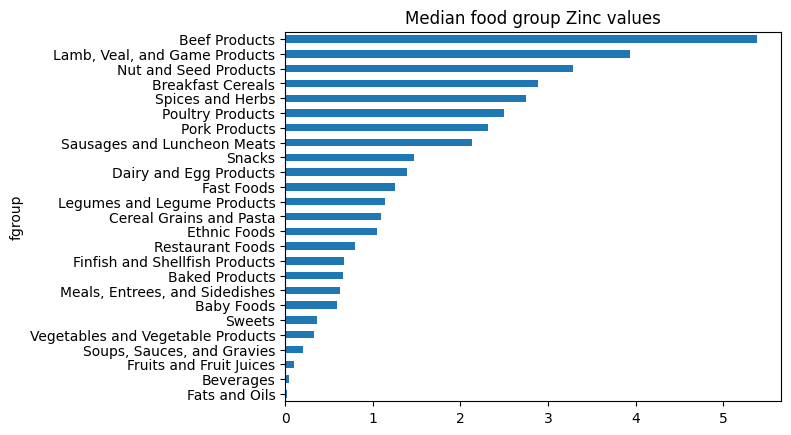

In [57]:
result["Zinc, Zn"].sort_values().plot(kind="barh", title="Median food group Zinc values")

In [95]:
# Which food has the most density in each nutrient?

dens = foodf.groupby(["nutgroup", "nutrient"])

In [97]:
def get_maximum(x):
    return x.loc[x.value.idxmax()]

max_foods = dens.apply(get_maximum, include_groups=False)[["value", "food"]]
max_foods

value  \
nutgroup    nutrient                                 
Amino Acids Alanine                          8.009   
            Arginine                         7.436   
            Aspartic acid                   10.203   
            Cystine                          1.307   
            Glutamic acid                   17.452   
...                                            ...   
Vitamins    Vitamin D2 (ergocalciferol)     28.100   
            Vitamin D3 (cholecalciferol)    27.400   
            Vitamin E (alpha-tocopherol)   149.400   
            Vitamin E, added                46.550   
            Vitamin K (phylloquinone)     1714.500   

                                                                                       food  
nutgroup    nutrient                                                                         
Amino Acids Alanine                                       Gelatins, dry powder, unsweetened  
            Arginine                                           Seeds, sesame flour, low-fat  
            Aspartic acid                                               Soy protein isolate  
            Cystine                            Seeds, cottonseed flour, low fat (glandless)  
            Glutamic acid                                               Soy protein isolate  
...                                                                                     ...  
Vitamins    Vitamin D2 (ergocalciferol)                             Mushrooms, maitake, raw  
            Vitamin D3 (cholecalciferol)                      Fish, halibut, Greenland, raw  
            Vitamin E (alpha-tocopherol)                                    Oil, wheat germ  
            Vitamin E, added              Cereals ready-to-eat, GENERAL MILLS, Multi-Gra...  
            Vitamin K (phylloquinone)                                  Spices, sage, ground  

[94 rows x 2 columns]

In [99]:
max_foods.loc["Amino Acids"]["food"]

nutrient
Alanine                           Gelatins, dry powder, unsweetened
Arginine                               Seeds, sesame flour, low-fat
Aspartic acid                                   Soy protein isolate
Cystine                Seeds, cottonseed flour, low fat (glandless)
Glutamic acid                                   Soy protein isolate
Glycine                           Gelatins, dry powder, unsweetened
Histidine                Whale, beluga, meat, dried (Alaska Native)
Hydroxyproline    KENTUCKY FRIED CHICKEN, Fried Chicken, ORIGINA...
Isoleucine        Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Leucine           Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Lysine            Seal, bearded (Oogruk), meat, dried (Alaska Na...
Methionine                    Fish, cod, Atlantic, dried and salted
Phenylalanine     Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Proline                           Gelatins, dry powder, unsweetened
Serine            Soy protein isolate, 